# 1. Load the data
# 2. Clean the data

In [ ]:
# prompt: load chicago_data.csv into a dataframe called df

import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/bakerfranke/bakerfranke.github.io/main/cs218/decision-tree-cards/chicago_data_with_northsouth.csv')
display(df.head())

,Layer,Name,GEOID,Population,Longitude,Latitude,SVI,ViolentCrime,Robbery,Pop_2019_2023,...,LowFoodAccess,GradRate,Unemployment,PerCapitaIncome,PovertyRate,TeenBirthRate,BirthRate,IndLivingDiff,city_side,city_side_numeric
0,Community area,Burnside,47,2514,-87.596470,41.728181,86.881610,131.229124,38.546748,2137.42191,...,94.253101,89.231810,18.610797,28116.3054,23.530290,42.335116,18.988707,14.792897,South,0
1,Community area,Hegewisch,55,9884,-87.556803,41.668188,75.582393,57.518202,11.841781,8885.92962,...,30.894174,84.527297,10.916237,30798.0004,11.097053,15.631576,18.638994,5.498263,South,0
2,Community area,Calumet Heights,48,13085,-87.572720,41.729673,53.811997,173.970198,43.039516,11643.03540,...,40.117691,95.361701,11.671174,39696.6985,15.476434,17.864434,14.118015,9.054761,South,0
3,Community area,North Center,5,35150,-87.683839,41.947811,12.334106,162.385518,68.244365,35443.73010,...,15.902327,97.273501,3.954678,89174.7293,4.675478,1.874414,30.058464,1.858621,North,1
4,Community area,Washington Heights,73,25075,-87.648897,41.717495,63.850764,316.849843,90.150590,25214.85960,...,64.855603,90.016052,10.854454,31651.0509,15.607126,17.467876,17.608794,6.616094,South,0


# 3. Select your features
# 4. Select your target

In [ ]:
# prompt: make a decision tree using to categorize "city_side" based on "GradRate", "TreeCanopy", and "CrowdedHousing"

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Make a list of column name for the features
features = ['GradRate', 'TreeCanopy','CrowdedHousing']
target = 'city_side'

# dropna() returns a copy of the dataframe with any empty/missing values removed
# assign it to a new variable df_model which we'll use for model-building
df_model = df.dropna()

# make X - a dataframe that has just the columns from the list of features
X = df_model[features]

# make y - a dataframe that just the column of target values
y = df_model[target]

# NOTE: X and y are frequently used as the variable names for the features and target respectively
# It's because of typical math language. i.e. "given this set of X's can we predict y?"


# 5. Split training and test data

In [ ]:
# seed the random number generator (for repeatable results)
r_seed = 1200

# Split X (the features) and y (the target) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=r_seed) # save 30% of the data test, the reamining 70% will be training


# 6. Train the model and Test it

Terminology:
- *Training the model* = "fitting the model" with the training data
- *Testing the model* = using the model to make predictions with the test data

In [ ]:
# Create Decision Tree Classifier (clf)
clf = DecisionTreeClassifier(min_samples_split=2, max_depth=10, random_state=r_seed)

# Train Decision Tree Classifier (clf now holds the trained model)
clf = clf.fit(X_train,y_train)

# Use clf - the trained model - to predict the response for test dataset
y_pred = clf.predict(X_test)

# 7. Evaluate the model
* Look at a confusion matrix
* Look at precision and recall
* (Optional) Visualize the model that was made (the decision tree)

Accuracy: 
0.7391304347826086
Confusion matrix: 
[[ 7  3]
 [ 3 10]]
Precision/Recall Report
              precision    recall  f1-score   support

       North       0.70      0.70      0.70        10
       South       0.77      0.77      0.77        13

    accuracy                           0.74        23
   macro avg       0.73      0.73      0.73        23
weighted avg       0.74      0.74      0.74        23



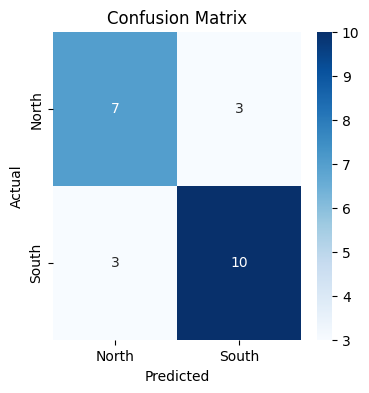

In [ ]:
# Common evaluation metrics compare x_test with y_pred
# y_test - the *actual* y values we saved for test data
# y_pred - the *prediected* y values from our model

print("Accuracy: ")
accuracy = metrics.accuracy_score(y_test, y_pred)
print(accuracy)

print("Confusion matrix: ")
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("Precision/Recall Report")
prec_recall = metrics.classification_report(y_test, y_pred)
print(prec_recall)


# Visualize the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

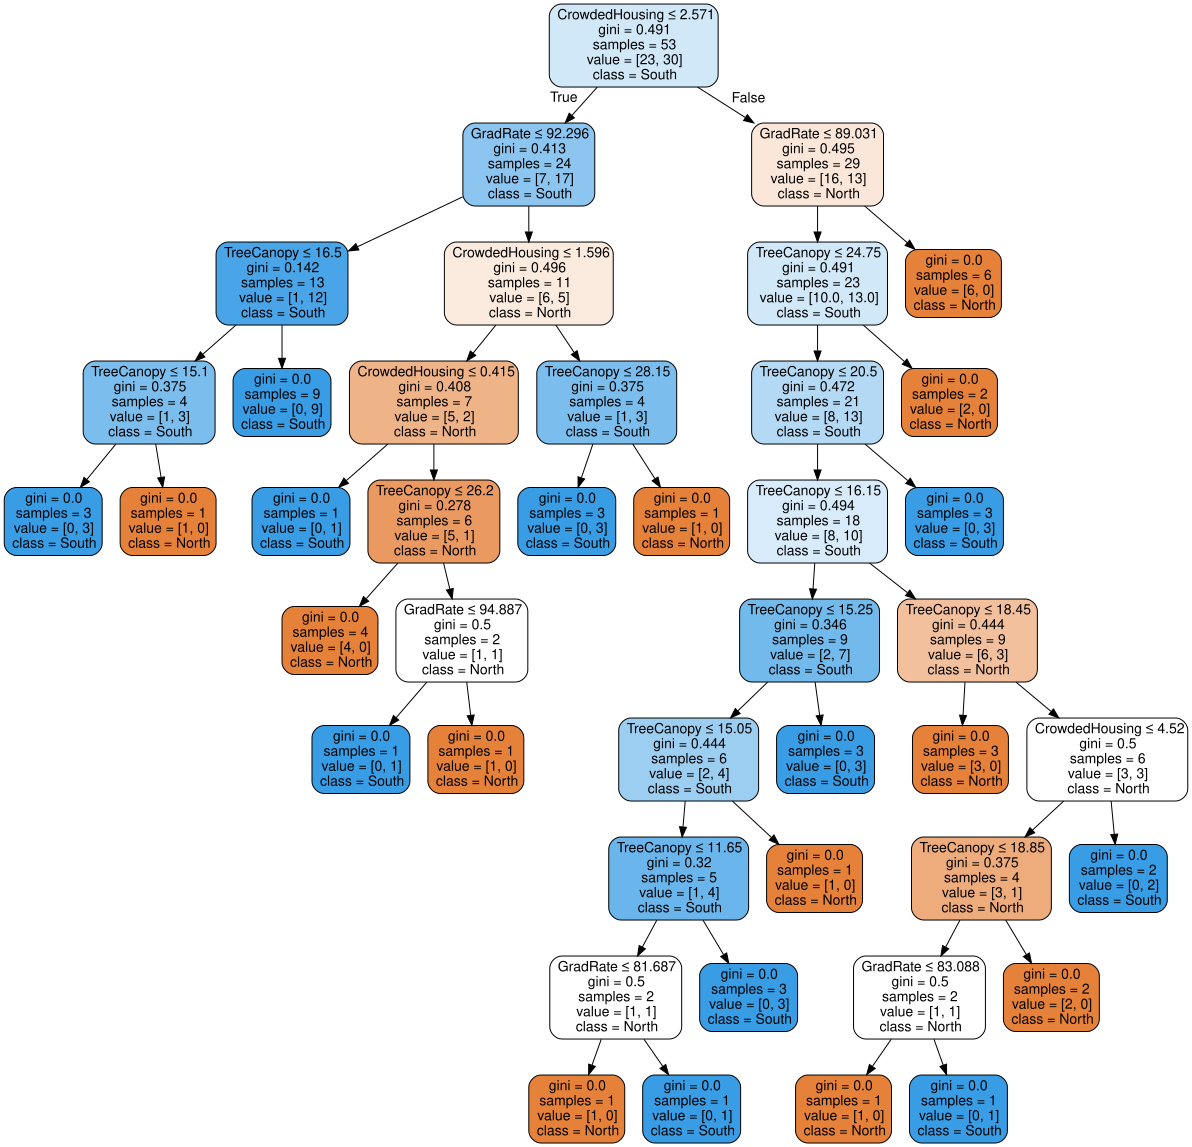

In [ ]:
#Optional: Visualize the Decision Tree (requires graphviz)
!pip install graphviz
from sklearn import tree
import graphviz

dot_data = tree.export_graphviz(clf, out_file=None,
                feature_names=features,
                class_names=clf.classes_,
                filled=True, rounded=True,
                special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Iterate/Improve

* Are you over-fitting?
* Can you tweak parameters on the model to improve accuracy/precision/recall?
* Is your training/test split good?

## Try a different model
* Try a random forest (below)


In [ ]:
# Example: define a community's feature values to predict
# [GradRate, TreeCanopy, CrowdedHousing]
my_test = [90.0, 25.0, 3.0]  # e.g. a typical North Side community

# prompt: make a random forest model

import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest classifier object
rf_clf = RandomForestClassifier(n_estimators=100, random_state=r_seed) # n_estimators is the number of trees

# Train Random Forest Classifier
rf_clf = rf_clf.fit(X_train, y_train)

# Predict the response for test dataset
y_pred_rf = rf_clf.predict(X_test)

# Model Evaluation
print("Random Forest Accuracy:", metrics.accuracy_score(y_test, y_pred_rf))
print(metrics.confusion_matrix(y_test, y_pred_rf))
print(metrics.classification_report(y_test, y_pred_rf))

# Example prediction with the Random Forest model
my_test_df = pd.DataFrame([my_test], columns=features)
result_rf = rf_clf.predict(my_test_df)
print("Random Forest prediction for my_test:", my_test,"=", result_rf)

Random Forest Accuracy: 0.8695652173913043
[[ 9  1]
 [ 2 11]]
              precision    recall  f1-score   support

       North       0.82      0.90      0.86        10
       South       0.92      0.85      0.88        13

    accuracy                           0.87        23
   macro avg       0.87      0.87      0.87        23
weighted avg       0.87      0.87      0.87        23



NameError: name 'my_test' is not defined